In [1]:
import warnings, os, math, time, json, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple, Dict
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
import mlflow

from data_loading import *
from loss_funcs import *

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
print(f"Device           : {DEVICE}")


PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
Device           : cuda


In [2]:
weather_cols_all = ['temperature_2m',
       'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
       'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance']

other_cols = [
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]
cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]
static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]
calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]
time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + static_cols + other_cols
print(f"y col is: {Y_COL}, group col is: {GROUP_COL}\n"
      f"features: {FUTURE_REALS}")


y col is: sum_of_kWh, group col is: eic_code
features: ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val : {val.shape}")
print(f"test: {test.shape}")


Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val : (293880, 38)
test: (295430, 38)


In [4]:
# # this cell samples locations, use only if training is too slow
#
# TARGET_STATIONS = 395
#
# station_stats = (
#     train.groupby(GROUP_COL)
#     .agg(rows=(Y_COL, "count"))
#     .reset_index()
#     .sort_values("rows", ascending=False)
# )
# sampled_stations = station_stats.sample(n=TARGET_STATIONS, random_state=42)[GROUP_COL].values
# train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# print(f"Train rows : {len(train):,}")
# print(f"Val rows   : {len(val):,}")
# print(f"Test rows  : {len(test):,}")


In [5]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")


training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14615


## Crossformer training (mirrors previous notebook, swaps loss to money_pct + 0.2·SMAPE)

In [6]:
# ── Config (mirrors previous-notebook hyperparameters as closely as possible)
# Previous setup used D_IN=15 (target + 6 weather + 2 static + 6 cyclical) with
# RevIN-style per-sample instance normalization inside the model. Categorical
# columns and prices were NOT fed in. We keep that recipe identical here -- the
# only training-side change is the loss function.

# ── Feature columns ───────────────────────────────────────────────────────────
WEATHER_FEATS = [
    "temperature_2m", "dew_point_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m", "shortwave_radiation",
]
STATIC_FEATS_REAL = ["latitude", "longitude"]
TIME_FEATS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

# Target placed FIRST so RevIN denormalization in the model uses index 0.
INPUT_FEATURES = [Y_COL] + WEATHER_FEATS + STATIC_FEATS_REAL + TIME_FEATS
D_IN = len(INPUT_FEATURES)   # 1 + 6 + 2 + 6 = 15
print(f"Input features (D_IN={D_IN}):", INPUT_FEATURES)

# Prices are needed by the money loss but NOT fed to the model.
# We keep them in a parallel array so the dataset can yield (x, y, prices).
PRICE_COLS = ["dam_price", "sell_bm_price", "buy_bm_price"]

# ── Sequence ──────────────────────────────────────────────────────────────────
SEQ_LEN  = 168     # 1-week lookback
PRED_LEN = 48      # 48-hour forecast
SEG_LEN  = 12      # 168 / 12 = 14 input segments, 48 / 12 = 4 output segments

# ── Model ─────────────────────────────────────────────────────────────────────
D_MODEL  = 256
N_HEADS  = 4
E_LAYERS = 3
D_FF     = 512
DROPOUT  = 0.1
WIN_SIZE = 2

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 256
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-2     # strong WD -- key to the previous run's generalization
MAX_EPOCHS    = 30
PATIENCE     = 5
TRAIN_STRIDE  = 6        # subsample windows for diversity vs speed

# Loss mixing: money_pct is the business objective, SMAPE provides a smooth,
# scale-free regularizer that gives gradients inside money_pct's deadband.
SMAPE_WEIGHT = 0.2

NUM_WORKERS = 0          # avoids fork/pickle stalls with the in-RAM dataset
CKPT_PATH   = "../models/crossformer/crossformer_best.pt"


Input features (D_IN=15): ['sum_of_kWh', 'temperature_2m', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [7]:
# ── Add cyclical time features expected by INPUT_FEATURES ─────────────────────
# The notebook's data already has Month/Hour/day_of_week numeric. We compute
# sin/cos pairs from the datetime column so values are bounded in [-1, 1].

def add_cyclical_time_features(df):
    dt = pd.to_datetime(df["datetime"])
    df["hour_sin"]  = np.sin(2 * np.pi * dt.dt.hour      / 24).astype("float32")
    df["hour_cos"]  = np.cos(2 * np.pi * dt.dt.hour      / 24).astype("float32")
    df["dow_sin"]   = np.sin(2 * np.pi * dt.dt.dayofweek / 7 ).astype("float32")
    df["dow_cos"]   = np.cos(2 * np.pi * dt.dt.dayofweek / 7 ).astype("float32")
    df["month_sin"] = np.sin(2 * np.pi * dt.dt.month     / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * dt.dt.month     / 12).astype("float32")
    return df

train = add_cyclical_time_features(train)
val   = add_cyclical_time_features(val)
test  = add_cyclical_time_features(test)

# Sanity-check that every required feature is present.
for col in INPUT_FEATURES + PRICE_COLS + ["time_idx", GROUP_COL]:
    assert col in train.columns, f"missing column {col!r} in train"

print("Cyclical features added.")
print("train cols sample:", [c for c in INPUT_FEATURES if c in train.columns])


Cyclical features added.
train cols sample: ['sum_of_kWh', 'temperature_2m', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'shortwave_radiation', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [8]:
class CrossformerDataset(Dataset):
    """
    Lazy sliding-window dataset for Crossformer (mirrors the previous
    project's CrossformerDataset). Adds a parallel `prices` block so the
    money loss can be computed on the future window without leaking
    prices into the model input.

    Each sample:
        x      : (seq_len, D_IN)        target at index 0, then weather/static/cyclical
        y      : (pred_len,)            future target (raw kWh)
        prices : (pred_len, 3)          dam_price, sell_bm_price, buy_bm_price
    """
    def __init__(self, df, group_col, target_col, feature_cols, price_cols,
                 seq_len, pred_len, stride=1):
        self.seq_len, self.pred_len = seq_len, pred_len
        assert feature_cols[0] == target_col, "target_col must be feature 0"

        self._feat: List[np.ndarray] = []
        self._prc:  List[np.ndarray] = []
        self._index: List[Tuple[int, int]] = []

        for _, gdf in tqdm(
            df.sort_values([group_col, "time_idx"]).groupby(group_col, sort=False),
            desc="Building dataset index", leave=False,
        ):
            feat = gdf[feature_cols].values.astype(np.float32)
            prc  = gdf[price_cols].values.astype(np.float32)
            g_idx = len(self._feat)
            self._feat.append(feat)
            self._prc.append(prc)
            n = len(feat)
            for s in range(0, n - seq_len - pred_len + 1, stride):
                self._index.append((g_idx, s))

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        g, s = self._index[idx]
        feat = self._feat[g]
        prc  = self._prc[g]
        e_in  = s + self.seq_len
        e_out = e_in + self.pred_len
        x      = torch.from_numpy(feat[s:e_in].copy())
        y      = torch.from_numpy(feat[e_in:e_out, 0].copy())
        prices = torch.from_numpy(prc[e_in:e_out].copy())
        return x, y, prices


print("Building train dataset …")
train_ds = CrossformerDataset(
    train, GROUP_COL, Y_COL, INPUT_FEATURES, PRICE_COLS,
    SEQ_LEN, PRED_LEN, stride=TRAIN_STRIDE,
)
print(f"  → {len(train_ds):,} samples")

# val dataset uses non-overlapping windows for fast per-epoch evaluation
print("Building val dataset (eval) …")
val_ds = CrossformerDataset(
    val, GROUP_COL, Y_COL, INPUT_FEATURES, PRICE_COLS,
    SEQ_LEN, PRED_LEN, stride=PRED_LEN,
)
print(f"  → {len(val_ds):,} samples")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


Building train dataset …


Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

  → 750,394 samples
Building val dataset (eval) …


Building dataset index:   0%|          | 0/395 [00:00<?, ?it/s]

  → 4,740 samples


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CROSSFORMER MODEL (verbatim port of the previous, working notebook).
#
# Key components:
#   * DSW_Embedding: per-variable segment embedding -> (B, D, num_seg, d_model)
#   * TwoStageAttentionLayer: cross-time then cross-dimension attention
#   * SegMerging: hierarchical halving of the segment axis
#   * DecoderLayer: self-attention + cross-attention with encoder memory
#   * Per-sample RevIN-style instance normalization inside forward()
#     (this is the single biggest reason the previous run generalized well)
# ══════════════════════════════════════════════════════════════════════════════

class DSW_Embedding(nn.Module):
    def __init__(self, seg_len: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.seg_len = seg_len
        self.proj = nn.Linear(seg_len, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        pad = (self.seg_len - T % self.seg_len) % self.seg_len
        if pad:
            x = F.pad(x, (0, 0, pad, 0))   # left-pad time
        num_seg = x.shape[1] // self.seg_len
        x = x.reshape(B, num_seg, self.seg_len, D).permute(0, 3, 1, 2)
        return self.drop(self.proj(x))   # (B, D, num_seg, d_model)


class TwoStageAttentionLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ct_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ct_norm1 = nn.LayerNorm(d_model)
        self.ct_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ct_norm2 = nn.LayerNorm(d_model)
        self.cd_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cd_norm1 = nn.LayerNorm(d_model)
        self.cd_ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.cd_norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, D, L, d = x.shape
        # Cross-time
        xt = x.reshape(B * D, L, d)
        out, _ = self.ct_attn(xt, xt, xt)
        xt = self.ct_norm1(xt + self.drop(out))
        xt = self.ct_norm2(xt + self.ct_ff(xt))
        x = xt.reshape(B, D, L, d)
        # Cross-dimension
        xd = x.permute(0, 2, 1, 3).reshape(B * L, D, d)
        out, _ = self.cd_attn(xd, xd, xd)
        xd = self.cd_norm1(xd + self.drop(out))
        xd = self.cd_norm2(xd + self.cd_ff(xd))
        x = xd.reshape(B, L, D, d).permute(0, 2, 1, 3)
        return x


class SegMerging(nn.Module):
    def __init__(self, d_model: int, win_size: int = 2):
        super().__init__()
        self.win = win_size
        self.norm = nn.LayerNorm(d_model * win_size)
        self.proj = nn.Linear(d_model * win_size, d_model)

    def forward(self, x):
        B, D, L, d = x.shape
        if L % self.win:
            x = F.pad(x, (0, 0, 0, self.win - L % self.win))
            L = x.shape[2]
        x = x.reshape(B, D, L // self.win, self.win * d)
        return self.proj(self.norm(x))


class CrossformerEncoder(nn.Module):
    def __init__(self, attn_layers, merge_layers):
        super().__init__()
        self.attn = attn_layers
        self.merge = merge_layers

    def forward(self, x):
        outs = []
        for i, layer in enumerate(self.attn):
            x = layer(x)
            outs.append(x)
            if i < len(self.merge):
                x = self.merge[i](x)
        return outs


class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.self_norm  = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.ff_norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mem):
        B, D, Lq, d = x.shape
        _, _, Lk, _ = mem.shape
        xt = x.reshape(B * D, Lq, d)
        sa, _ = self.self_attn(xt, xt, xt)
        xt = self.self_norm(xt + self.drop(sa))
        mk = mem.reshape(B * D, Lk, d)
        ca, _ = self.cross_attn(xt, mk, mk)
        xt = self.cross_norm(xt + self.drop(ca))
        xt = self.ff_norm(xt + self.ff(xt))
        return xt.reshape(B, D, Lq, d)


class Crossformer(nn.Module):
    """Multivariate input (B,T,D), univariate target output (B,pred_len).
    Per-sample RevIN: each feature is normalized by lookback-window mean/std,
    target output is denormalized using the target feature stats only."""
    def __init__(self, seq_len, pred_len, seg_len, d_in,
                 d_model=256, n_heads=4, e_layers=3, d_ff=512,
                 dropout=0.1, win_size=2):
        super().__init__()
        self.pred_len = pred_len
        self.seg_len = seg_len
        self.embed = DSW_Embedding(seg_len, d_model, dropout)

        pad_in  = (seg_len - seq_len  % seg_len) % seg_len
        pad_out = (seg_len - pred_len % seg_len) % seg_len
        self.in_seg_num  = (seq_len  + pad_in)  // seg_len
        self.out_seg_num = (pred_len + pad_out) // seg_len

        self.enc_pos = nn.Parameter(torch.randn(1, 1, self.in_seg_num,  d_model) * 0.02)
        self.dec_pos = nn.Parameter(torch.randn(1, 1, self.out_seg_num, d_model) * 0.02)
        self.dim_pos = nn.Parameter(torch.randn(1, d_in, 1,             d_model) * 0.02)

        self.encoder = CrossformerEncoder(
            nn.ModuleList([TwoStageAttentionLayer(d_model, n_heads, d_ff, dropout)
                           for _ in range(e_layers)]),
            nn.ModuleList([SegMerging(d_model, win_size) for _ in range(e_layers - 1)]),
        )
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(e_layers)
        ])
        self.out_proj = nn.Linear(d_model, seg_len)

    def forward(self, x):
        B, T, D = x.shape
        # RevIN-style instance norm
        mu  = x.mean(dim=1, keepdim=True)
        sig = x.std (dim=1, keepdim=True).clamp(1e-5)
        x_n = (x - mu) / sig

        enc_in   = self.embed(x_n) + self.enc_pos + self.dim_pos
        enc_outs = self.encoder(enc_in)

        dec_q = (self.dec_pos + self.dim_pos).expand(B, -1, -1, -1)
        for dec_layer, mem in zip(self.dec_layers, reversed(enc_outs)):
            dec_q = dec_layer(dec_q, mem)

        out = self.out_proj(dec_q)
        out = out.reshape(B, D, -1)
        out = out[:, 0, :self.pred_len]            # target only

        # Denormalize using target feature stats only
        out = out * sig[:, 0, 0:1] + mu[:, 0, 0:1]
        return out


# ── Instantiate & smoke-test ──────────────────────────────────────────────────
model = Crossformer(
    seq_len=SEQ_LEN, pred_len=PRED_LEN, seg_len=SEG_LEN, d_in=D_IN,
    d_model=D_MODEL, n_heads=N_HEADS, e_layers=E_LAYERS,
    d_ff=D_FF, dropout=DROPOUT, win_size=WIN_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Crossformer parameters : {n_params:,}")

with torch.no_grad():
    dummy = torch.randn(4, SEQ_LEN, D_IN).to(DEVICE)
    out = model(dummy)
    assert out.shape == (4, PRED_LEN), f"unexpected shape {out.shape}"
print(f"Forward OK: {tuple(dummy.shape)} -> {tuple(out.shape)}")


Crossformer parameters : 5,814,540
Forward OK: (4, 168, 15) -> (4, 48)


In [10]:
# ── Differentiable losses (torch) ─────────────────────────────────────────────
# money_pct mirrors loss_funcs.money_pct exactly (piecewise linear in y_pred,
# fully differentiable). SMAPE is computed on raw kWh -- on z-scored values
# the denominator crosses zero and the loss explodes. Both losses live in the
# same units (% on raw kWh) so they sum cleanly.

def money_pct_torch(y_true, y_pred, dam, sell, buy, eps=1e-6):
    p  = dam  / 1000.0
    sp = sell / 1000.0
    bp = buy  / 1000.0
    min_spend = y_true * p
    ordered   = y_pred * p
    diff      = y_pred - y_true
    real_spend = (
        ordered
        - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
        - torch.where(diff < 0, bp * diff, torch.zeros_like(diff))
    )
    excess = real_spend - min_spend
    denom  = (min_spend.sum().abs() / 100.0) + eps
    return excess.sum() / denom


def smape_torch(y_true, y_pred, eps=1e-6):
    # Returns SMAPE in percent.
    return 100.0 * torch.mean(
        2.0 * torch.abs(y_pred - y_true)
        / (torch.abs(y_pred) + torch.abs(y_true) + eps)
    )


def combined_loss(y_pred, y_true, prices, smape_weight=SMAPE_WEIGHT):
    """y_pred, y_true: (B, pred_len) raw kWh.  prices: (B, pred_len, 3)."""
    m = money_pct_torch(y_true, y_pred, prices[..., 0], prices[..., 1], prices[..., 2])
    s = smape_torch(y_true, y_pred)
    loss = m + smape_weight * s
    return loss, {"money_pct": float(m.detach()), "smape": float(s.detach())}


In [ ]:
# ── Optimizer / scheduler / scaler ────────────────────────────────────────────
optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode="min", factor=0.5, patience=2)
scaler    = torch.cuda.amp.GradScaler()


@torch.no_grad()
def evaluate_on_loader(loader) -> Dict[str, float]:
    """Sum-aggregated SMAPE and money_pct over the loader on raw kWh."""
    model.eval()
    total_excess, total_min = 0.0, 0.0
    smape_sum, smape_n = 0.0, 0
    eps = 1e-6
    for xb, yb, pb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        pb = pb.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            pred = model(xb).float()

        p, sp, bp = pb[..., 0]/1000.0, pb[..., 1]/1000.0, pb[..., 2]/1000.0
        min_spend = yb * p
        ordered   = pred * p
        diff      = pred - yb
        real_spend = (ordered
                      - torch.where(diff > 0, sp * diff, torch.zeros_like(diff))
                      - torch.where(diff < 0, bp * diff, torch.zeros_like(diff)))
        total_excess += (real_spend - min_spend).sum().item()
        total_min    += min_spend.sum().item()

        s_elem = (2.0 * torch.abs(pred - yb)
                  / (torch.abs(pred) + torch.abs(yb) + eps))
        smape_sum += s_elem.sum().item()
        smape_n   += s_elem.numel()

    return {
        "money_pct": total_excess / (total_min / 100.0 + 1e-9),
        "smape":     100.0 * smape_sum / max(smape_n, 1),
    }


# ── MLflow run setup ──────────────────────────────────────────────────────────
mlflow.set_experiment("crossformer_money_smape")
mlflow.start_run(run_name=f"crossformer_{int(time.time())}")
mlflow.log_params({
    "seq_len": SEQ_LEN, "pred_len": PRED_LEN, "seg_len": SEG_LEN, "d_in": D_IN,
    "d_model": D_MODEL, "n_heads": N_HEADS, "e_layers": E_LAYERS, "d_ff": D_FF,
    "dropout": DROPOUT, "win_size": WIN_SIZE,
    "batch_size": BATCH_SIZE, "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS, "patience": PATIENCE, "train_stride": TRAIN_STRIDE,
    "smape_weight": SMAPE_WEIGHT, "n_params": n_params,
    "input_features": json.dumps(INPUT_FEATURES),
    "train_dt_range": f"{train['datetime'].min()} .. {train['datetime'].max()}",
    "val_dt_range":   f"{val['datetime'].min()} .. {val['datetime'].max()}",
    "test_dt_range":  f"{test['datetime'].min()} .. {test['datetime'].max()}",
    "n_train_windows": len(train_ds), "n_val_windows": len(val_ds),
})


# ── Training loop ─────────────────────────────────────────────────────────────
best_val_money = float("inf")
patience_count = 0
history = {"train_loss": [], "train_money": [], "train_smape": [],
           "val_money": [], "val_smape": []}

print(f"Starting training — {MAX_EPOCHS} epochs on {DEVICE}")
print(f"  Steps / epoch : {len(train_loader):,}")

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss, ep_money, ep_smape, steps = 0.0, 0.0, 0.0, 0
    t0 = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{MAX_EPOCHS}", leave=False)
    for xb, yb, pb in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        pb = pb.to(DEVICE, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            pred = model(xb)
            loss, parts = combined_loss(pred.float(), yb, pb, smape_weight=SMAPE_WEIGHT)

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimiser)
        scaler.update()

        epoch_loss += float(loss.detach()); ep_money += parts["money_pct"]; ep_smape += parts["smape"]
        steps += 1
        pbar.set_postfix(loss=f"{loss.item():.3f}",
                         m_pct=f"{parts['money_pct']:.2f}",
                         smape=f"{parts['smape']:.2f}")

    train_loss  = epoch_loss / steps
    train_money = ep_money   / steps
    train_smape = ep_smape   / steps
    val_metrics = evaluate_on_loader(val_loader)
    scheduler.step(val_metrics["money_pct"])
    elapsed = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_money"].append(train_money)
    history["train_smape"].append(train_smape)
    history["val_money"].append(val_metrics["money_pct"])
    history["val_smape"].append(val_metrics["smape"])

    mlflow.log_metrics({
        "train_loss": train_loss,
        "train_money_pct": train_money,
        "train_smape": train_smape,
        "val_money_pct": val_metrics["money_pct"],
        "val_smape": val_metrics["smape"],
        "lr": optimiser.param_groups[0]["lr"],
    }, step=epoch)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train loss {train_loss:6.3f}  m_pct {train_money:5.2f}  smape {train_smape:5.2f} | "
        f"val m_pct {val_metrics['money_pct']:5.2f}  smape {val_metrics['smape']:5.2f} | "
        f"{elapsed:.0f}s"
    )

    if val_metrics["money_pct"] < best_val_money:
        best_val_money = val_metrics["money_pct"]
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"  ✓ Checkpoint saved (val money_pct {best_val_money:.3f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

mlflow.log_metric("best_val_money_pct", best_val_money)
mlflow.log_artifact(CKPT_PATH)
print(f"\nBest val money_pct: {best_val_money:.3f}  —  {CKPT_PATH}")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("Best weights loaded.")


2026/04/26 12:37:44 INFO mlflow.tracking.fluent: Experiment with name 'crossformer_money_smape' does not exist. Creating a new experiment.


Starting training — 30 epochs on cuda
  Steps / epoch : 2,931


Epoch 01/30:   0%|          | 0/2931 [00:00<?, ?it/s]

Epoch 01/30 | train loss  3.742  m_pct  2.34  smape  6.99 | val m_pct  2.98  smape  5.65 | 214s
  ✓ Checkpoint saved (val money_pct 2.976)


Epoch 02/30:   0%|          | 0/2931 [00:00<?, ?it/s]

...

Epoch 06/30:   0%|          | 0/2931 [00:00<?, ?it/s]

Epoch 06/30 | train loss  2.144  m_pct  1.14  smape  5.02 | val m_pct  2.96  smape  5.64 | 220s


Epoch 07/30:   0%|          | 0/2931 [00:00<?, ?it/s]

Epoch 07/30 | train loss  2.052  m_pct  1.07  smape  4.90 | val m_pct  2.80  smape  5.67 | 220s


Epoch 08/30:   0%|          | 0/2931 [00:00<?, ?it/s]

In [11]:
@torch.no_grad()
def predict_split(context_df, forecast_start: int, eval_cutoff: int, split_name: str = "split"):
    """
    Sliding-window inference over [forecast_start … eval_cutoff].
    Each PRED_LEN-hour block uses ground-truth context from the preceding
    SEQ_LEN hours (direct multi-step, no recursion).

    Returns DataFrame with [GROUP_COL, time_idx, datetime, Y_COL, pred,
    dam_price, sell_bm_price, buy_bm_price].
    """
    model.eval()
    rows = []

    for grp in tqdm(context_df[GROUP_COL].unique(), desc=f"Inferring {split_name}"):
        gdf = (context_df[context_df[GROUP_COL] == grp]
               .sort_values("time_idx").reset_index(drop=True))
        feat = gdf[INPUT_FEATURES].values.astype(np.float32)
        prc  = gdf[PRICE_COLS].values.astype(np.float32)
        tidx = gdf["time_idx"].values
        dts  = gdf["datetime"].values
        tmap = {int(t): i for i, t in enumerate(tidx)}

        t = forecast_start
        while t <= eval_cutoff:
            ctx_start = t - SEQ_LEN
            if ctx_start not in tmap or t not in tmap:
                t += PRED_LEN; continue
            s = tmap[ctx_start]; e = tmap[t]
            if e - s != SEQ_LEN:
                t += PRED_LEN; continue

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
                xb = torch.from_numpy(feat[s:e].copy()).unsqueeze(0).to(DEVICE)
                pred = model(xb).squeeze(0).float().cpu().numpy()

            for step in range(PRED_LEN):
                ti = t + step
                if ti not in tmap: break
                pos = tmap[ti]
                rows.append({
                    GROUP_COL: grp,
                    "time_idx": int(ti),
                    "datetime": dts[pos],
                    Y_COL:           float(feat[pos, 0]),
                    "pred":          float(pred[step]),
                    "dam_price":     float(prc[pos, 0]),
                    "sell_bm_price": float(prc[pos, 1]),
                    "buy_bm_price":  float(prc[pos, 2]),
                })
            t += PRED_LEN

    return pd.DataFrame(rows)


# Build context dataframes that include the SEQ_LEN history before each split.
# train and val/test already have continuous time_idx.
context_for_val  = pd.concat([train, val ], ignore_index=True)
context_for_test = pd.concat([train, val, test], ignore_index=True)

# Make sure cyclical features are present on the concatenated frames.
# (They are, since we added them to train/val/test individually before concat.)

print("Running validation inference …")
val_eval  = predict_split(context_for_val,  training_cutoff + 1, val_cutoff, split_name="val")
print(f"  val_eval rows : {len(val_eval):,}")

print("Running test inference …")
test_eval = predict_split(context_for_test, val_cutoff + 1, test_cutoff, split_name="test")
print(f"  test_eval rows: {len(test_eval):,}")


Running validation inference …


Inferring val:   0%|          | 0/395 [00:00<?, ?it/s]

  val_eval rows : 243,392
Running test inference …


Inferring test:   0%|          | 0/395 [00:00<?, ?it/s]

  test_eval rows: 244,682


In [12]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

def bias(y_true, y_pred):
    return float(np.sum(np.asarray(y_pred, float) - np.asarray(y_true, float)))

# --- Validation ---
val_smape_v     = smape(val_eval[Y_COL], val_eval["pred"])
val_rmse_v      = rmse (val_eval[Y_COL], val_eval["pred"])
val_mape_v      = mape (val_eval[Y_COL], val_eval["pred"])
val_mae_v       = mae  (val_eval[Y_COL], val_eval["pred"])
val_bias_v      = bias (val_eval[Y_COL], val_eval["pred"])
val_money_v     = money    (val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval["pred"], *_prices(val_eval))

# --- Test ---
test_smape_v     = smape(test_eval[Y_COL], test_eval["pred"])
test_rmse_v      = rmse (test_eval[Y_COL], test_eval["pred"])
test_mape_v      = mape (test_eval[Y_COL], test_eval["pred"])
test_mae_v       = mae  (test_eval[Y_COL], test_eval["pred"])
test_bias_v      = bias (test_eval[Y_COL], test_eval["pred"])
test_money_v     = money    (test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval["pred"], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"MAE       : {val_mae_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"BIAS      : {val_bias_v:.4f}")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"MAE       : {test_mae_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"BIAS      : {test_bias_v:.4f}")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape": val_smape_v, "val_rmse": val_rmse_v, "val_mape": val_mape_v,
    "val_mae": val_mae_v, "val_bias": val_bias_v,
    "val_money": val_money_v, "val_money_pct": val_money_pct_v,
    "test_smape": test_smape_v, "test_rmse": test_rmse_v, "test_mape": test_mape_v,
    "test_mae": test_mae_v, "test_bias": test_bias_v,
    "test_money": test_money_v, "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")


── Validation ──────────────────────────────────────────────
Aligned samples : 243,392
MAE       : 3.7683
RMSE      : 7.3118
MAPE      : 23.02 %
SMAPE     : 0.2058
BIAS      : 1875.0176
MONEY     : 2036995.2425
MONEY_PCT : 8.5623%
── Test ────────────────────────────────────────────────────
Aligned samples : 244,682
MAE       : 3.7379
RMSE      : 8.1086
MAPE      : 23.53 %
SMAPE     : 0.2001
BIAS      : 101114.4605
MONEY     : 2118921.3198
MONEY_PCT : 8.7850%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [13]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:   grp,
            "n":         len(gdf),
            "SMAPE":     smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":      rmse (gdf[Y_COL], gdf["pred"]),
            "MAPE":      mape (gdf[Y_COL], gdf["pred"]),
            "MONEY":     money    (gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT": money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("MONEY_PCT")

test_station_metrics = per_station_metrics(test_eval)
print("Top-10 best stations (test MONEY_PCT):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test MONEY_PCT):")
print(test_station_metrics.tail(10).to_string(index=False))


Top-10 best stations (test MONEY_PCT):
        eic_code   n    SMAPE      RMSE      MAPE        MONEY  MONEY_PCT
62Z4603551328872   2 0.083742  1.153584  8.027063     0.090321   0.398164
62Z6969613150684 746 0.073302  3.334846  7.450215  5023.222810   3.362462
62Z2673921373211 746 0.073335  4.362742  7.556302  6502.245402   3.401728
62Z4026142936382 746 0.073939  3.262030  7.629852  4795.115763   3.407256
62Z9572466865833 746 0.074564  6.137523  7.546375  9319.899938   3.437417
62Z7036676557692 746 0.118850  2.115573 12.668797  2650.493844   4.650939
62Z8461462561806 746 0.128911  6.978269 13.612382  9552.074938   5.322622
62Z713390564870T 746 0.128476  7.979761 13.657823 10900.409039   5.344422
62Z6605113197287 746 0.129411  8.705241 13.641240 12019.796716   5.373794
62Z1908641756932 746 0.132278 10.965342 13.744941 15039.915817   5.426037

Bottom-10 worst stations (test MONEY_PCT):
        eic_code   n    SMAPE      RMSE       MAPE         MONEY  MONEY_PCT
62Z3982298183754 746 0.2194

Best  station (MONEY_PCT): 62Z4603551328872


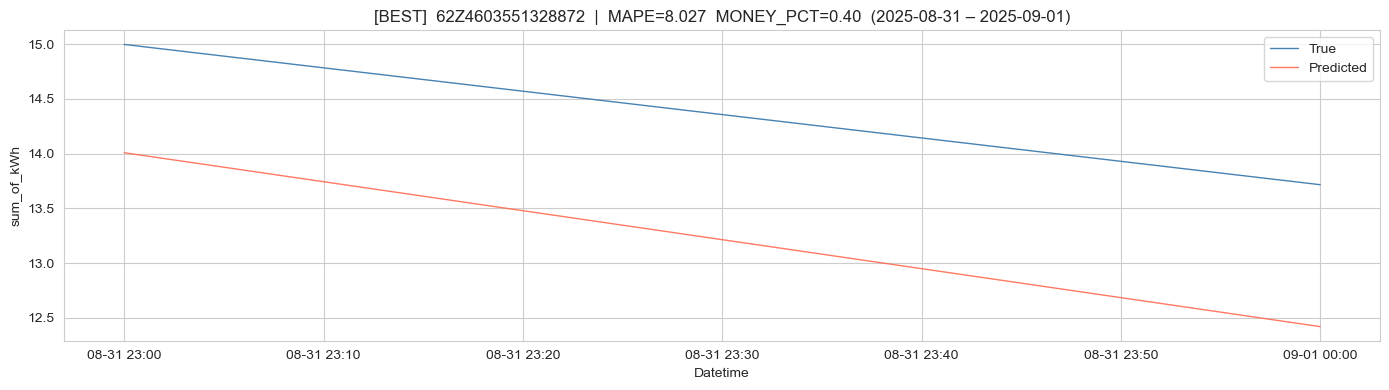

Worst station (MONEY_PCT): 62Z6035944504754


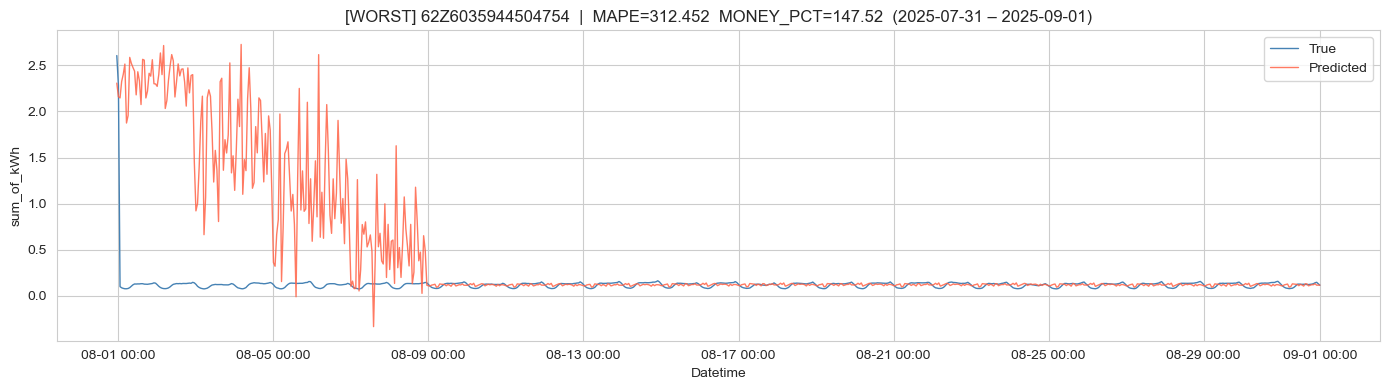

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]
print(f"Best  station (MONEY_PCT): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")
print(f"Worst station (MONEY_PCT): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")
